In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
#load a stock file

DATA_DIR = r"E:\Pyhton code\Data Sets\archive\huge stock price data"

# Pick a well-known, data-rich stock
STOCK = r"E:\Pyhton code\Data Sets\archive\huge stock price data\Stocks\aapl.us.txt"
file_path = os.path.join(DATA_DIR, STOCK)

df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(df.shape)
df.head()

(8364, 7)


,Date,Open,High,Low,Close,Volume,OpenInt
0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0
1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0
2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0
3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0
4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0


Date range: 1984-09-07 00:00:00 to 2017-11-10 00:00:00

Missing values:
 Date       0
Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64


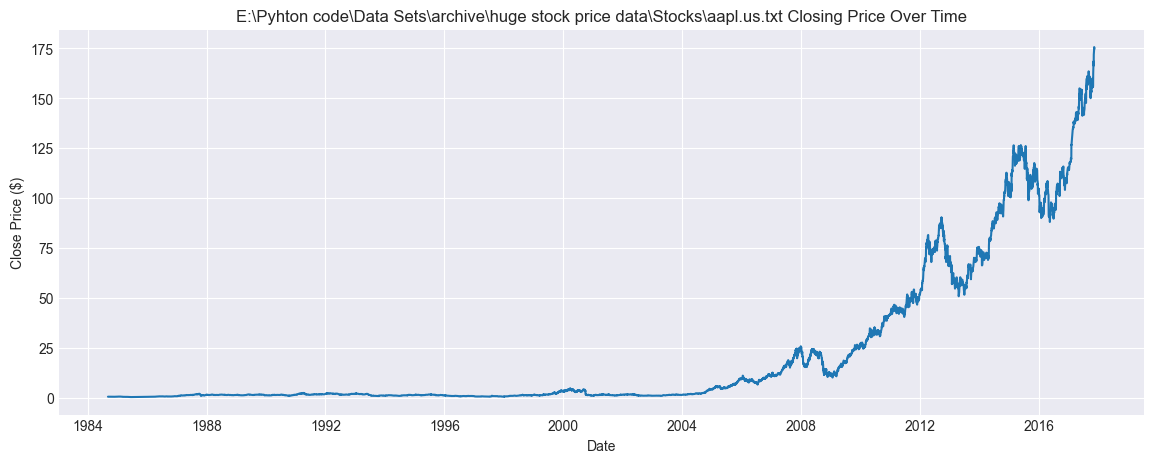

In [3]:
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("\nMissing values:\n", df.isnull().sum())

plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Close'])
plt.title(f"{STOCK} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.show()

In [4]:
#select features & scale
# Using Close price for prediction
close_prices = df[['Close']].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

print("Scaled data shape:", scaled_data.shape)
print("Sample scaled values:", scaled_data[:5].flatten())

Scaled data shape: (8364, 1)
Sample scaled values: [0.00110258 0.0010881  0.00113189 0.00105868 0.00119033]


In [5]:
#create sequences
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 60
X, y = create_sequences(scaled_data, WINDOW_SIZE)

print("X shape:", X.shape)  # (samples, window_size)
print("y shape:", y.shape)

X shape: (8304, 60)
y shape: (8304,)


In [6]:
#time-based train/test split
split_ratio = 0.8
split_idx = int(len(X) * split_ratio)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Reshape for LSTM: (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (6643, 60, 1) X_test: (1661, 60, 1)
y_train: (6643,) y_test: (1661,)


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0
GPU available: []


In [8]:
#build lstm model
model = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=64, return_sequences=False),
    Dropout(0.2),
    Dense(units=32, activation='relu'),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#set up callbacks
os.makedirs("models", exist_ok=True)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="models/best_lstm_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [10]:
#train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 5.7424e-04
Epoch 1: val_loss improved from None to 0.00267, saving model to models/best_lstm_model.keras

Epoch 1: finished saving model to models/best_lstm_model.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - loss: 1.9069e-04 - val_loss: 0.0027
Epoch 2/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 3.5435e-05
Epoch 2: val_loss did not improve from 0.00267
208/208 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 3.5147e-05 - val_loss: 0.0043
Epoch 3/50
207/208 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 3.9978e-05
Epoch 3: val_loss improved from 0.00267 to 0.00181, saving model to models/best_lstm_model.keras

Epoch 3: finished saving model to models/best_lstm_model.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 3.5028e-05 - val_loss: 0.0018
Epoch 4/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.9804e-05
Epoch 4: val_loss improved from 0.00181 to 0.00051, saving model to models/best_lstm_model.keras

Epoch 

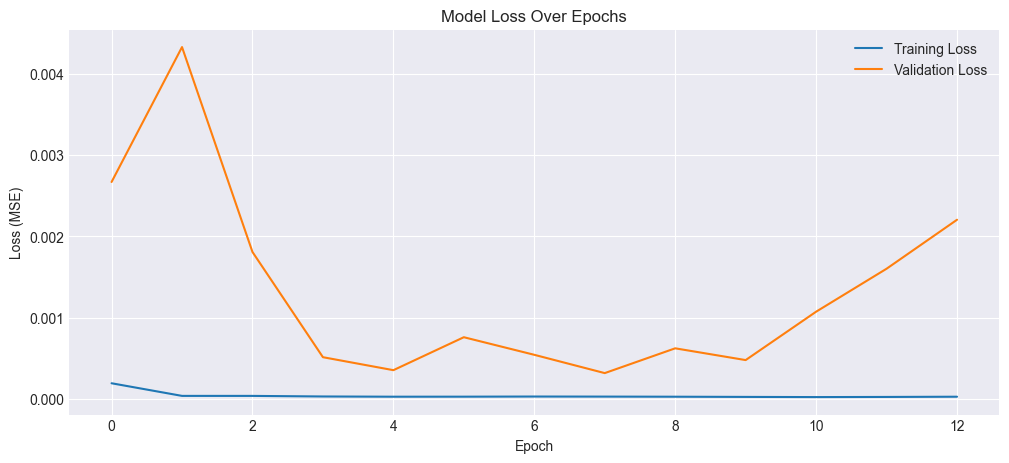

Final training loss: 0.000025
Final validation loss: 0.002204


In [11]:
#plot training vs validation loss
plt.figure(figsize=(12,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

print(f"Final training loss: {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

In [12]:
# evluation % visualization
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

best_model = load_model("models/best_lstm_model.keras")
print("Model loaded successfully")

Model loaded successfully


In [13]:
#predict on test set
predictions_scaled = best_model.predict(X_test)

# Inverse transform to get actual price values
predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Predictions shape:", predictions.shape)
print("Sample predictions vs actual:")
for i in range(5):
    print(f"Predicted: {predictions[i][0]:.2f}  |  Actual: {y_test_actual[i][0]:.2f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
Predictions shape: (1661, 1)
Sample predictions vs actual:
Predicted: 43.15  |  Actual: 42.91
Predicted: 43.00  |  Actual: 42.36
Predicted: 42.79  |  Actual: 42.57
Predicted: 42.57  |  Actual: 43.05
Predicted: 42.40  |  Actual: 42.57


In [14]:
#compute metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print(f"RMSE: ${rmse:.2f}")
print(f"MAE:  ${mae:.2f}")
print(f"MAPE: {mape:.2f}%")

RMSE: $3.12
MAE:  $2.49
MAPE: 2.90%


In [15]:
#naive baseline comparison
naive_predictions = y_test_actual[:-1]  # shift by one
naive_actual = y_test_actual[1:]

naive_rmse = np.sqrt(mean_squared_error(naive_actual, naive_predictions))
naive_mae = mean_absolute_error(naive_actual, naive_predictions)

print("=== Model vs Naive Baseline ===")
print(f"LSTM RMSE:  ${rmse:.2f}   |   Naive RMSE:  ${naive_rmse:.2f}")
print(f"LSTM MAE:   ${mae:.2f}   |   Naive MAE:   ${naive_mae:.2f}")

if rmse < naive_rmse:
    print("\n✅ LSTM model outperforms the naive baseline.")
else:
    print("\n⚠️ LSTM model does NOT beat the naive baseline — needs improvement.")

=== Model vs Naive Baseline ===
LSTM RMSE:  $3.12   |   Naive RMSE:  $1.40
LSTM MAE:   $2.49   |   Naive MAE:   $0.98

⚠️ LSTM model does NOT beat the naive baseline — needs improvement.


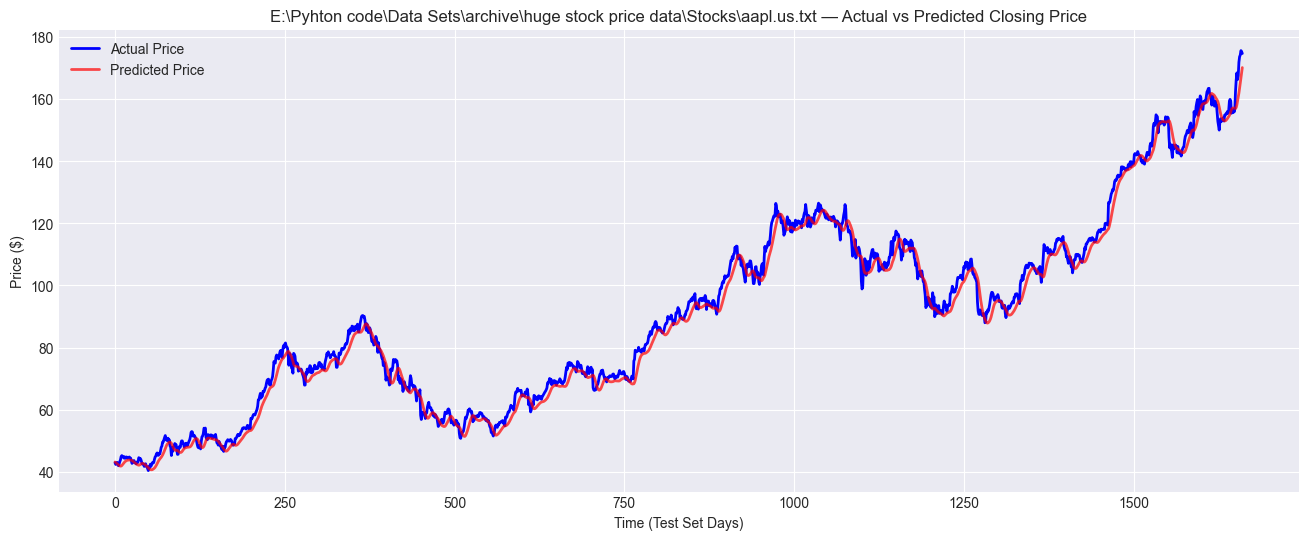

In [16]:
#plot actual vs predicted
plt.figure(figsize=(16,6))
plt.plot(y_test_actual, label='Actual Price', color='blue', linewidth=2)
plt.plot(predictions, label='Predicted Price', color='red', linewidth=2, alpha=0.7)
plt.title(f'{STOCK} — Actual vs Predicted Closing Price')
plt.xlabel('Time (Test Set Days)')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

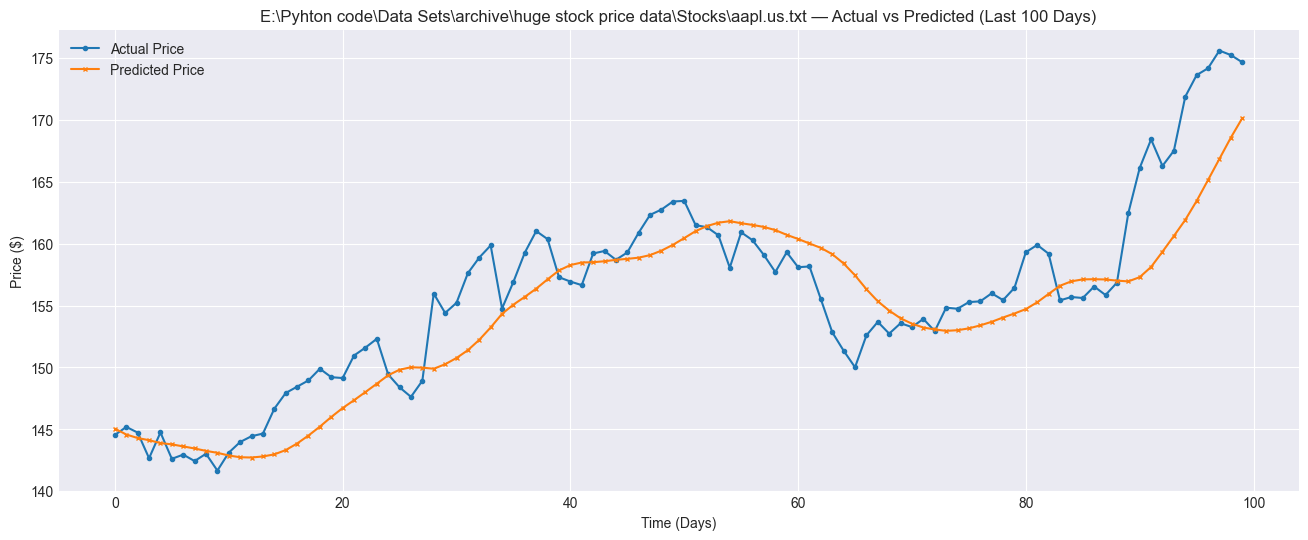

In [17]:
#zoomed-in view (last 100 days for clarity)
plt.figure(figsize=(16,6))
plt.plot(y_test_actual[-100:], label='Actual Price', marker='o', markersize=3)
plt.plot(predictions[-100:], label='Predicted Price', marker='x', markersize=3)
plt.title(f'{STOCK} — Actual vs Predicted (Last 100 Days)')
plt.xlabel('Time (Days)')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [18]:
#Feature Engineering + Multivariate model
df2 = df.copy()

# Engineered features
df2['Return'] = df2['Close'].pct_change()
df2['MA7'] = df2['Close'].rolling(7).mean()
df2['MA21'] = df2['Close'].rolling(21).mean()

# Target: NEXT day's return (what we actually want to predict)
df2['Target'] = df2['Close'].pct_change().shift(-1)

df2 = df2.dropna().reset_index(drop=True)

FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'MA7', 'MA21']
print(df2.shape)
df2[FEATURES + ['Target']].head()

(8343, 11)


,Open,High,Low,Close,Volume,Return,MA7,MA21,Target
0,0.40593,0.40593,0.39443,0.39699,27211851,-0.022024,0.400277,0.420042,0.000000
1,0.39699,0.39956,0.39699,0.39699,13099922,0.000000,0.398260,0.418762,-0.009648
2,0.39699,0.39956,0.39316,0.39316,34933112,-0.009648,0.397167,0.417420,-0.029301
3,0.39316,0.39316,0.38164,0.38164,101750813,-0.029301,0.395707,0.415164,-0.006760
4,0.38164,0.39186,0.37906,0.37906,50969114,-0.006760,0.393511,0.413396,-0.043924


In [19]:
#Time based split (before scaling- avoid leakage)
split_ratio = 0.8
split_point = int(len(df2) * split_ratio)

train_df = df2.iloc[:split_point]
test_df = df2.iloc[split_point:]

print("Train rows:", len(train_df), " Test rows:", len(test_df))

Train rows: 6674  Test rows: 1669


In [20]:
#Fit scalaers on TRAIN only, then transform both
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

train_features_scaled = feature_scaler.fit_transform(train_df[FEATURES])
test_features_scaled = feature_scaler.transform(test_df[FEATURES])

train_target_scaled = target_scaler.fit_transform(train_df[['Target']])
test_target_scaled = target_scaler.transform(test_df[['Target']])

In [21]:
#Build multivariate sequences
def create_multivariate_sequences(features_scaled, target_scaled, raw_close, window_size=60):
    X, y, base_close, next_close = [], [], [], []
    for i in range(window_size, len(features_scaled)):
        X.append(features_scaled[i-window_size:i])
        y.append(target_scaled[i-1][0])
        base_close.append(raw_close[i-1])   # last known actual close
        next_close.append(raw_close[i])     # actual next-day close
    return np.array(X), np.array(y), np.array(base_close), np.array(next_close)

WINDOW_SIZE = 60

X_train2, y_train2, base_close_train, next_close_train = create_multivariate_sequences(
    train_features_scaled, train_target_scaled, train_df['Close'].values, WINDOW_SIZE
)
X_test2, y_test2, base_close_test, next_close_test = create_multivariate_sequences(
    test_features_scaled, test_target_scaled, test_df['Close'].values, WINDOW_SIZE
)

print("X_train2:", X_train2.shape, "X_test2:", X_test2.shape)

X_train2: (6614, 60, 8) X_test2: (1609, 60, 8)


In [22]:
#build improved lstm model
model2 = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(X_train2.shape[1], X_train2.shape[2])),
    Dropout(0.2),
    LSTM(units=64, return_sequences=False),
    Dropout(0.2),
    Dense(units=32, activation='relu'),
    Dense(units=1)
])

model2.compile(optimizer='adam', loss='mean_squared_error')
model2.summary()

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,825 (210.25 KB)

 Trainable params: 53,825 (210.25 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
#train
early_stop2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint2 = ModelCheckpoint(filepath="models/best_lstm_model_v2.keras", monitor='val_loss', save_best_only=True, verbose=1)

history2 = model2.fit(
    X_train2, y_train2,
    validation_data=(X_test2, y_test2),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop2, checkpoint2],
    verbose=1
)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0469
Epoch 1: val_loss improved from None to 0.00231, saving model to models/best_lstm_model_v2.keras

Epoch 1: finished saving model to models/best_lstm_model_v2.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - loss: 0.0140 - val_loss: 0.0023
Epoch 2/50
206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0032
Epoch 2: val_loss improved from 0.00231 to 0.00064, saving model to models/best_lstm_model_v2.keras

Epoch 2: finished saving model to models/best_lstm_model_v2.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 0.0031 - val_loss: 6.3932e-04
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0028
Epoch 3: val_loss did not improve from 0.00064
207/207 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.0026 - val_loss: 6.5345e-04
Epoch 4/50
206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0024
Epoch 4: val_loss did not improve from 0.00064
207/207 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.0023 - val_

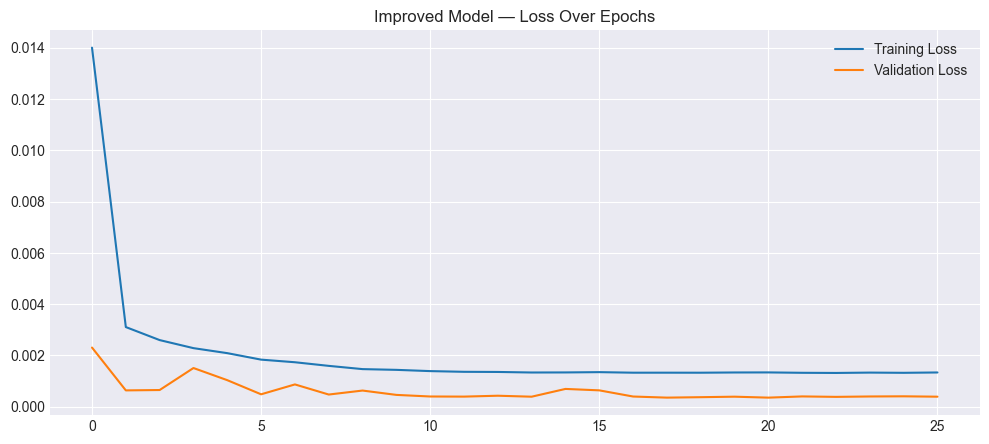

In [24]:
#plot loss
plt.figure(figsize=(12,5))
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Improved Model — Loss Over Epochs')
plt.legend()
plt.show()

In [25]:
#predict returns -> reconstruct prices -> evaluate vs naive baseline
pred_return_scaled = model2.predict(X_test2)
pred_return = target_scaler.inverse_transform(pred_return_scaled).flatten()

# Reconstruct predicted price from predicted return
predicted_price2 = base_close_test * (1 + pred_return)
actual_price2 = next_close_test

rmse2 = np.sqrt(mean_squared_error(actual_price2, predicted_price2))
mae2 = mean_absolute_error(actual_price2, predicted_price2)

naive_pred2 = base_close_test  # naive: tomorrow = today
naive_rmse2 = np.sqrt(mean_squared_error(actual_price2, naive_pred2))
naive_mae2 = mean_absolute_error(actual_price2, naive_pred2)

print("=== Improved Model vs Naive Baseline ===")
print(f"LSTM v2 RMSE: ${rmse2:.2f}   |   Naive RMSE: ${naive_rmse2:.2f}")
print(f"LSTM v2 MAE:  ${mae2:.2f}   |   Naive MAE:  ${naive_mae2:.2f}")

if rmse2 < naive_rmse2:
    print("\n✅ Improved LSTM now outperforms the naive baseline!")
else:
    print("\n⚠️ Still not beating naive — but check how close it is now.")

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
=== Improved Model vs Naive Baseline ===
LSTM v2 RMSE: $1.42   |   Naive RMSE: $1.42
LSTM v2 MAE:  $1.01   |   Naive MAE:  $1.00

⚠️ Still not beating naive — but check how close it is now.


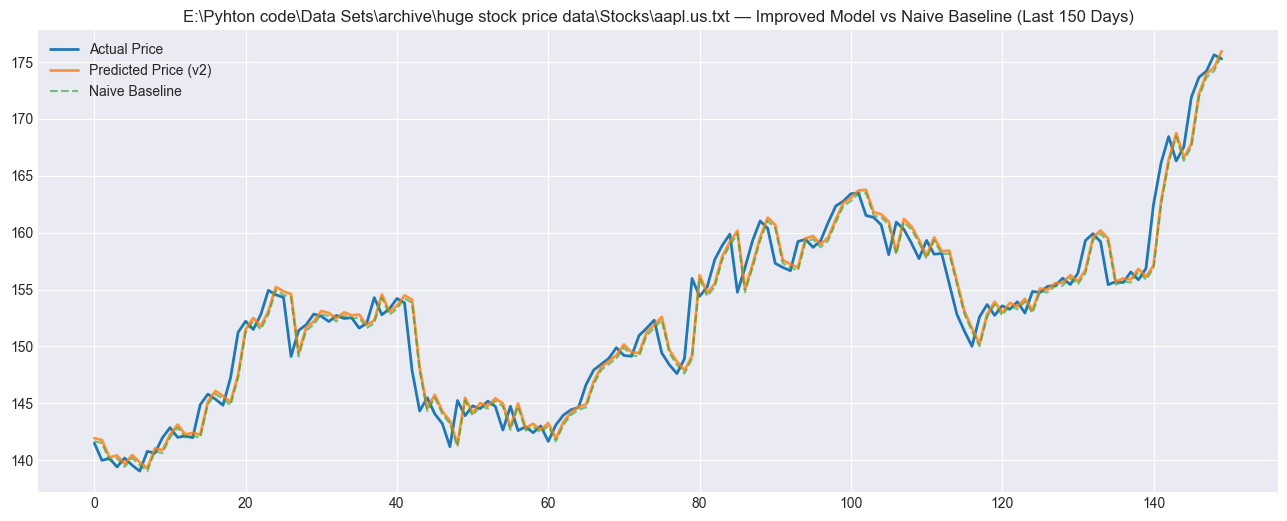

In [26]:
plt.figure(figsize=(16,6))
plt.plot(actual_price2[-150:], label='Actual Price', linewidth=2)
plt.plot(predicted_price2[-150:], label='Predicted Price (v2)', linewidth=2, alpha=0.8)
plt.plot(naive_pred2[-150:], label='Naive Baseline', linestyle='--', alpha=0.6)
plt.title(f'{STOCK} — Improved Model vs Naive Baseline (Last 150 Days)')
plt.legend()
plt.show()

In [27]:
import joblib
import json

os.makedirs("saved_model", exist_ok=True)

# Save model (already have best_lstm_model_v2.keras from checkpoint)
model2.save("saved_model/lstm_stock_model.keras")

# Save scalers
joblib.dump(feature_scaler, "saved_model/feature_scaler.pkl")
joblib.dump(target_scaler, "saved_model/target_scaler.pkl")

# Save config so the app knows exact settings used
config = {
    "features": FEATURES,
    "window_size": WINDOW_SIZE
}
with open("saved_model/config.json", "w") as f:
    json.dump(config, f)

print("Saved: model, scalers, config -> saved_model/")

Saved: model, scalers, config -> saved_model/


# Add Trend Classification

In [28]:
df3 = df.copy()

# Basic trend/momentum features
df3['Return'] = df3['Close'].pct_change()
df3['MA7'] = df3['Close'].rolling(7).mean()
df3['MA21'] = df3['Close'].rolling(21).mean()

# RSI (Relative Strength Index)
delta = df3['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df3['RSI'] = 100 - (100 / (1 + rs))

# MACD
ema12 = df3['Close'].ewm(span=12, adjust=False).mean()
ema26 = df3['Close'].ewm(span=26, adjust=False).mean()
df3['MACD'] = ema12 - ema26
df3['MACD_signal'] = df3['MACD'].ewm(span=9, adjust=False).mean()

# Rolling volatility & momentum
df3['Volatility21'] = df3['Return'].rolling(21).std()
df3['Momentum10'] = df3['Close'].pct_change(10)

df3 = df3.dropna().reset_index(drop=True)
print(df3.shape)
df3.tail()

(8343, 15)


,Date,Open,High,Low,Close,Volume,OpenInt,Return,MA7,MA21,RSI,MACD,MACD_signal,Volatility21,Momentum10
8338,2017-11-06,171.75,174.36,171.10,173.63,34901241,0,0.010182,168.047143,160.436667,74.079270,3.806569,2.161603,0.013120,0.115802
8339,2017-11-07,173.29,174.51,173.29,174.18,24424877,0,0.003168,169.720000,161.336667,76.437390,4.245416,2.578366,0.013123,0.112687
8340,2017-11-08,174.03,175.61,173.71,175.61,24451166,0,0.008210,171.075714,162.301905,88.811995,4.654936,2.993680,0.013080,0.126789
8341,2017-11-09,174.48,175.46,172.52,175.25,29533086,0,-0.002050,172.050000,163.219048,87.471264,4.894020,3.373748,0.013192,0.117310
8342,2017-11-10,175.11,175.38,174.27,174.67,25130494,0,-0.003310,173.247143,164.134762,85.827068,4.979296,3.694857,0.013184,0.075091


In [29]:
# create trend label (N day forward return -> up/down/flat)
HORIZON = 10       # predict trend over next 10 trading days (~2 weeks)
THRESHOLD = 0.02   # ±2% = flat zone

df3['Future_Return'] = df3['Close'].shift(-HORIZON) / df3['Close'] - 1

def label_trend(x):
    if x > THRESHOLD:
        return 2  # Up
    elif x < -THRESHOLD:
        return 0  # Down
    else:
        return 1  # Flat

df3['Trend_Label'] = df3['Future_Return'].apply(label_trend)
df3 = df3.dropna().reset_index(drop=True)

print(df3['Trend_Label'].value_counts(normalize=True))
print("\n0=Down, 1=Flat, 2=Up")

Trend_Label
2    0.446058
0    0.339374
1    0.214569
Name: proportion, dtype: float64

0=Down, 1=Flat, 2=Up


In [30]:
#time based split
FEATURES_TREND = ['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 
                   'MA7', 'MA21', 'RSI', 'MACD', 'MACD_signal', 'Volatility21', 'Momentum10']

split_point3 = int(len(df3) * 0.8)
train_df3 = df3.iloc[:split_point3]
test_df3 = df3.iloc[split_point3:]

print("Train:", len(train_df3), " Test:", len(test_df3))

Train: 6666  Test: 1667


In [31]:
#scale features
trend_scaler = MinMaxScaler()
train_feat_scaled3 = trend_scaler.fit_transform(train_df3[FEATURES_TREND])
test_feat_scaled3 = trend_scaler.transform(test_df3[FEATURES_TREND])

In [32]:
#build sequence for classification
def create_classification_sequences(features_scaled, labels, window_size=60):
    X, y = [], []
    for i in range(window_size, len(features_scaled)):
        X.append(features_scaled[i-window_size:i])
        y.append(labels[i])
    return np.array(X), np.array(y)

WINDOW_SIZE = 60

X_train3, y_train3 = create_classification_sequences(train_feat_scaled3, train_df3['Trend_Label'].values, WINDOW_SIZE)
X_test3, y_test3 = create_classification_sequences(test_feat_scaled3, test_df3['Trend_Label'].values, WINDOW_SIZE)

print("X_train3:", X_train3.shape, "y_train3:", y_train3.shape)
print("X_test3:", X_test3.shape, "y_test3:", y_test3.shape)

X_train3: (6606, 60, 13) y_train3: (6606,)
X_test3: (1607, 60, 13) y_test3: (1607,)


In [33]:
#build lstm classifier
from tensorflow.keras.utils import to_categorical

y_train3_cat = to_categorical(y_train3, num_classes=3)
y_test3_cat = to_categorical(y_test3, num_classes=3)

trend_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train3.shape[1], X_train3.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # Down / Flat / Up
])

trend_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
trend_model.summary()

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,171 (215.51 KB)

 Trainable params: 55,171 (215.51 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
#train 
early_stop3 = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
checkpoint3 = ModelCheckpoint(filepath="models/trend_classifier.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

history3 = trend_model.fit(
    X_train3, y_train3_cat,
    validation_data=(X_test3, y_test3_cat),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop3, checkpoint3],
    verbose=1
)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4259 - loss: 1.0581
Epoch 1: val_accuracy improved from None to 0.32358, saving model to models/trend_classifier.keras

Epoch 1: finished saving model to models/trend_classifier.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.4443 - loss: 1.0484 - val_accuracy: 0.3236 - val_loss: 1.1404
Epoch 2/50
206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4436 - loss: 1.0461
Epoch 2: val_accuracy improved from 0.32358 to 0.35594, saving model to models/trend_classifier.keras

Epoch 2: finished saving model to models/trend_classifier.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.4482 - loss: 1.0444 - val_accuracy: 0.3559 - val_loss: 1.1610
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4492 - loss: 1.0414
Epoch 3: val_accuracy improved from 0.35594 to 0.42439, saving model to models/trend_classifier.keras

Epoch 3: finished saving model to models/trend_classifier.keras
207

In [35]:
#Evaluate - accuracy vs random/majority baseline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

pred_probs = trend_model.predict(X_test3)
pred_labels = np.argmax(pred_probs, axis=1)

acc = accuracy_score(y_test3, pred_labels)

# Baselines
random_baseline = 1/3
majority_class = np.bincount(y_test3).argmax()
majority_baseline_acc = np.mean(y_test3 == majority_class)

print(f"Model Accuracy:        {acc*100:.2f}%")
print(f"Random Baseline:       {random_baseline*100:.2f}%")
print(f"Majority Class Baseline: {majority_baseline_acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test3, pred_labels, target_names=['Down', 'Flat', 'Up']))

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
Model Accuracy:        42.19%
Random Baseline:       33.33%
Majority Class Baseline: 42.44%

Classification Report:
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00       431
        Flat       0.37      0.44      0.41       494
          Up       0.45      0.67      0.54       682

    accuracy                           0.42      1607
   macro avg       0.27      0.37      0.31      1607
weighted avg       0.31      0.42      0.35      1607



C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

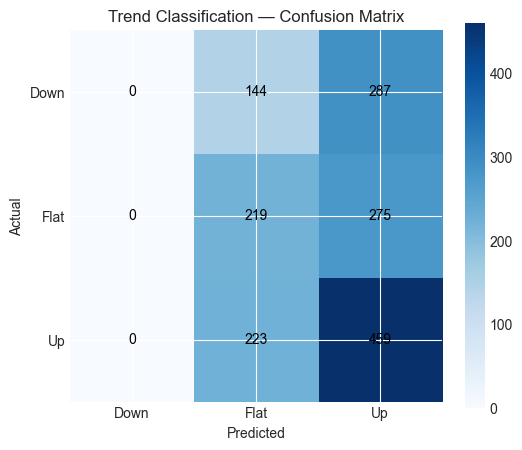

In [36]:
cm = confusion_matrix(y_test3, pred_labels)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks([0,1,2], ['Down','Flat','Up'])
plt.yticks([0,1,2], ['Down','Flat','Up'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Trend Classification — Confusion Matrix')
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

In [37]:
#check actual class balanace first
print("Train label distribution:")
print(train_df3['Trend_Label'].value_counts(normalize=True).sort_index())
print("\n0=Down, 1=Flat, 2=Up")

Train label distribution:
Trend_Label
0    0.355686
1    0.190969
2    0.453345
Name: proportion, dtype: float64

0=Down, 1=Flat, 2=Up


In [38]:
# add class weights to force the model to pay attention to minority classes
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train3),
    y=y_train3
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.9342384386932542), 1: np.float64(1.7407114624505928), 2: np.float64(0.7379356568364611)}


In [39]:
#rebuild model
trend_model2 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train3.shape[1], X_train3.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

trend_model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop4 = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
checkpoint4 = ModelCheckpoint(filepath="models/trend_classifier_v2.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

history4 = trend_model2.fit(
    X_train3, y_train3_cat,
    validation_data=(X_test3, y_test3_cat),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop4, checkpoint4],
    verbose=1
)

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3103 - loss: 1.1060
Epoch 1: val_accuracy improved from None to 0.30741, saving model to models/trend_classifier_v2.keras

Epoch 1: finished saving model to models/trend_classifier_v2.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.3423 - loss: 1.0973 - val_accuracy: 0.3074 - val_loss: 1.2637
Epoch 2/50
206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4016 - loss: 1.0817
Epoch 2: val_accuracy did not improve from 0.30741
207/207 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.3759 - loss: 1.0962 - val_accuracy: 0.3074 - val_loss: 1.1531
Epoch 3/50
206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3035 - loss: 1.0950
Epoch 3: val_accuracy did not improve from 0.30741
207/207 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.3311 - loss: 1.0954 - val_accuracy: 0.3074 - val_loss: 1.3160
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3714 - loss: 1.0931
Epoch 4: val_accuracy d

In [40]:
#re-evaluate
pred_probs2 = trend_model2.predict(X_test3)
pred_labels2 = np.argmax(pred_probs2, axis=1)

acc2 = accuracy_score(y_test3, pred_labels2)

print(f"Model Accuracy (weighted):  {acc2*100:.2f}%")
print(f"Random Baseline:            {random_baseline*100:.2f}%")
print(f"Majority Class Baseline:    {majority_baseline_acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test3, pred_labels2, target_names=['Down', 'Flat', 'Up'], zero_division=0))

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
Model Accuracy (weighted):  30.74%
Random Baseline:            33.33%
Majority Class Baseline:    42.44%

Classification Report:
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00       431
        Flat       0.31      1.00      0.47       494
          Up       0.00      0.00      0.00       682

    accuracy                           0.31      1607
   macro avg       0.10      0.33      0.16      1607
weighted avg       0.09      0.31      0.14      1607



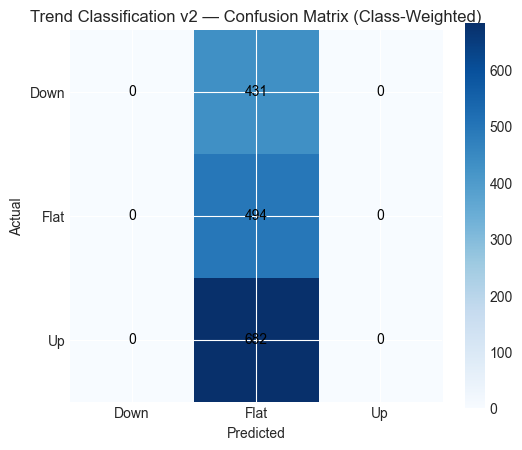

In [41]:
cm2 = confusion_matrix(y_test3, pred_labels2)
plt.figure(figsize=(6,5))
plt.imshow(cm2, cmap='Blues')
plt.colorbar()
plt.xticks([0,1,2], ['Down','Flat','Up'])
plt.yticks([0,1,2], ['Down','Flat','Up'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Trend Classification v2 — Confusion Matrix (Class-Weighted)')
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm2[i, j], ha='center', va='center', color='black')
plt.show()

In [42]:
# Binary: only keep clearly directional moves, drop ambiguous "flat" days entirely
df3['Binary_Label'] = np.where(df3['Future_Return'] > THRESHOLD, 1,
                         np.where(df3['Future_Return'] < -THRESHOLD, 0, np.nan))

df3_binary = df3.dropna(subset=['Binary_Label']).reset_index(drop=True)
df3_binary['Binary_Label'] = df3_binary['Binary_Label'].astype(int)

print("Rows kept:", len(df3_binary), "out of", len(df3))
print(df3_binary['Binary_Label'].value_counts(normalize=True))
print("0=Down, 1=Up")

Rows kept: 6545 out of 8333
Binary_Label
1    0.567914
0    0.432086
Name: proportion, dtype: float64
0=Down, 1=Up


In [43]:
#split, scale (only train data)
split_point_b = int(len(df3_binary) * 0.8)
train_b = df3_binary.iloc[:split_point_b]
test_b = df3_binary.iloc[split_point_b:]

scaler_b = MinMaxScaler()
train_feat_b = scaler_b.fit_transform(train_b[FEATURES_TREND])
test_feat_b = scaler_b.transform(test_b[FEATURES_TREND])

print("Train:", len(train_b), " Test:", len(test_b))
print("Train class balance:", train_b['Binary_Label'].value_counts(normalize=True).to_dict())

Train: 5236  Test: 1309
Train class balance: {1: 0.5582505729564553, 0: 0.4417494270435447}


In [44]:
#build sequence
X_train_b, y_train_b = create_classification_sequences(train_feat_b, train_b['Binary_Label'].values, WINDOW_SIZE)
X_test_b, y_test_b = create_classification_sequences(test_feat_b, test_b['Binary_Label'].values, WINDOW_SIZE)

print("X_train_b:", X_train_b.shape, "X_test_b:", X_test_b.shape)

X_train_b: (5176, 60, 13) X_test_b: (1249, 60, 13)


In [45]:
#simpler binary model (reduce complexity)
binary_model = Sequential([
    LSTM(32, return_sequences=False, input_shape=(X_train_b.shape[1], X_train_b.shape[2])),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

binary_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
binary_model.summary()

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 32)             │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,433 (25.13 KB)

 Trainable params: 6,433 (25.13 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
#train (no class weighting)
early_stop5 = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
checkpoint5 = ModelCheckpoint(filepath="models/binary_trend_classifier.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

history5 = binary_model.fit(
    X_train_b, y_train_b,
    validation_data=(X_test_b, y_test_b),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop5, checkpoint5],
    verbose=1
)

Epoch 1/50
159/162 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5498 - loss: 0.6872
Epoch 1: val_accuracy improved from None to 0.61409, saving model to models/binary_trend_classifier.keras

Epoch 1: finished saving model to models/binary_trend_classifier.keras
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.5543 - loss: 0.6862 - val_accuracy: 0.6141 - val_loss: 0.6709
Epoch 2/50
160/162 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5596 - loss: 0.6827
Epoch 2: val_accuracy did not improve from 0.61409
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5527 - loss: 0.6839 - val_accuracy: 0.6141 - val_loss: 0.6666
Epoch 3/50
160/162 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5728 - loss: 0.6821
Epoch 3: val_accuracy did not improve from 0.61409
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5618 - loss: 0.6836 - val_accuracy: 0.6141 - val_loss: 0.6669
Epoch 4/50
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5811 - loss: 0.6752
Epoch 4: val_accur

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Model Accuracy:     61.41%
Random Baseline:    50.00%
Majority Baseline:  61.41%

Classification Report:
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00       482
          Up       0.61      1.00      0.76       767

    accuracy                           0.61      1249
   macro avg       0.31      0.50      0.38      1249
weighted avg       0.38      0.61      0.47      1249



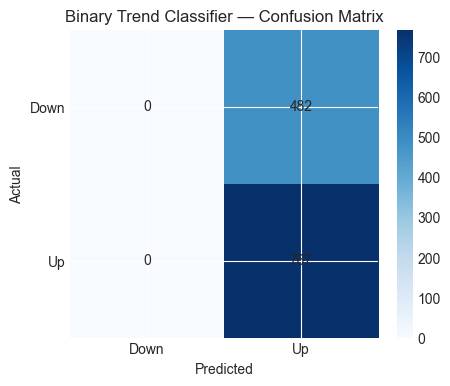

In [47]:
pred_probs_b = binary_model.predict(X_test_b)
pred_labels_b = (pred_probs_b > 0.5).astype(int).flatten()

acc_b = accuracy_score(y_test_b, pred_labels_b)
majority_b = max(np.mean(y_test_b == 0), np.mean(y_test_b == 1))

print(f"Model Accuracy:     {acc_b*100:.2f}%")
print(f"Random Baseline:    50.00%")
print(f"Majority Baseline:  {majority_b*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test_b, pred_labels_b, target_names=['Down','Up'], zero_division=0))

cm_b = confusion_matrix(y_test_b, pred_labels_b)
plt.figure(figsize=(5,4))
plt.imshow(cm_b, cmap='Blues')
plt.colorbar()
plt.xticks([0,1], ['Down','Up'])
plt.yticks([0,1], ['Down','Up'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_b[i,j], ha='center', va='center')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Binary Trend Classifier — Confusion Matrix')
plt.show()

In [48]:
#walk forward validation setup
def walk_forward_splits(data_len, n_splits=5, min_train_size=0.4):
    """Generate expanding-window train/test split indices"""
    min_train = int(data_len * min_train_size)
    remaining = data_len - min_train
    test_size = remaining // n_splits
    
    splits = []
    for i in range(n_splits):
        train_end = min_train + i * test_size
        test_end = min(train_end + test_size, data_len)
        if test_end <= train_end:
            break
        splits.append((0, train_end, train_end, test_end))
    return splits

splits = walk_forward_splits(len(df3_binary), n_splits=5)
for i, (ts, te, vs, ve) in enumerate(splits):
    print(f"Fold {i+1}: Train[0:{te}] ({te} rows) -> Test[{vs}:{ve}] ({ve-vs} rows)")

Fold 1: Train[0:2618] (2618 rows) -> Test[2618:3403] (785 rows)
Fold 2: Train[0:3403] (3403 rows) -> Test[3403:4188] (785 rows)
Fold 3: Train[0:4188] (4188 rows) -> Test[4188:4973] (785 rows)
Fold 4: Train[0:4973] (4973 rows) -> Test[4973:5758] (785 rows)
Fold 5: Train[0:5758] (5758 rows) -> Test[5758:6543] (785 rows)


In [49]:
#run binary classifier across each fold, track results
fold_results = []

for fold_i, (train_start, train_end, test_start, test_end) in enumerate(splits):
    fold_train = df3_binary.iloc[train_start:train_end]
    fold_test = df3_binary.iloc[test_start:test_end]
    
    if len(fold_train) < WINDOW_SIZE + 50 or len(fold_test) < WINDOW_SIZE + 10:
        print(f"Fold {fold_i+1}: skipped (not enough data)")
        continue
    
    fold_scaler = MinMaxScaler()
    fold_train_feat = fold_scaler.fit_transform(fold_train[FEATURES_TREND])
    fold_test_feat = fold_scaler.transform(fold_test[FEATURES_TREND])
    
    X_tr, y_tr = create_classification_sequences(fold_train_feat, fold_train['Binary_Label'].values, WINDOW_SIZE)
    X_te, y_te = create_classification_sequences(fold_test_feat, fold_test['Binary_Label'].values, WINDOW_SIZE)
    
    fold_model = Sequential([
        LSTM(32, input_shape=(X_tr.shape[1], X_tr.shape[2])),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    fold_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    fold_model.fit(X_tr, y_tr, validation_data=(X_te, y_te), epochs=30, batch_size=32, callbacks=[es], verbose=0)
    
    preds = (fold_model.predict(X_te, verbose=0) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_te, preds)
    majority = max(np.mean(y_te==0), np.mean(y_te==1))
    test_period = f"{fold_test['Date'].iloc[0].date()} to {fold_test['Date'].iloc[-1].date()}"
    
    fold_results.append({
        'fold': fold_i+1, 'test_period': test_period, 
        'accuracy': acc, 'majority_baseline': majority, 
        'beats_baseline': acc > majority
    })
    print(f"Fold {fold_i+1} ({test_period}): Acc={acc*100:.2f}% | Majority={majority*100:.2f}% | Beats baseline: {acc > majority}")

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 1 (1997-08-14 to 2001-04-02): Acc=56.41% | Majority=58.34% | Beats baseline: False


C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 2 (2001-04-03 to 2005-02-23): Acc=54.62% | Majority=59.86% | Beats baseline: False


C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 3 (2005-02-24 to 2008-12-26): Acc=60.83% | Majority=60.83% | Beats baseline: False


C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 4 (2008-12-31 to 2013-02-14): Acc=68.14% | Majority=64.28% | Beats baseline: True


C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 5 (2013-02-15 to 2017-10-25): Acc=63.45% | Majority=63.45% | Beats baseline: False


In [50]:
#summary
results_df = pd.DataFrame(fold_results)
print(results_df)
print(f"\nAverage accuracy across folds: {results_df['accuracy'].mean()*100:.2f}%")
print(f"Average majority baseline:     {results_df['majority_baseline'].mean()*100:.2f}%")
print(f"Folds where model beat baseline: {results_df['beats_baseline'].sum()} / {len(results_df)}")

   fold               test_period  accuracy  majority_baseline  beats_baseline
0     1  1997-08-14 to 2001-04-02  0.564138           0.583448           False
1     2  2001-04-03 to 2005-02-23  0.546207           0.598621           False
2     3  2005-02-24 to 2008-12-26  0.608276           0.608276           False
3     4  2008-12-31 to 2013-02-14  0.681379           0.642759            True
4     5  2013-02-15 to 2017-10-25  0.634483           0.634483           False

Average accuracy across folds: 60.69%
Average majority baseline:     61.35%
Folds where model beat baseline: 1 / 5


# Project Report: AAPL Stock Prediction — LSTM (Regression + Classification)

## Dataset
- Source: Kaggle "Huge Stock Market Dataset" (borismarjanovic)
- Stock used: AAPL (aapl.us.txt)
- Range: 1984-09-07 to 2017-11-10 (~8,364 rows)
- Columns: Date, Open, High, Low, Close, Volume

## What We Built

### 1. Price Regression (LSTM)
- v1: Predicted raw Close price using only Close history → looked accurate but was just lagging (mimicking yesterday's price). Failed to beat naive baseline (RMSE $8.92 vs $1.40).
- v2: Predicted % return instead of price, added OHLCV + MA7/MA21 features, fixed data leakage (scaler fit on train only). Result: RMSE $1.42 ≈ Naive baseline $1.42 — matched, did not beat it.
- **Conclusion:** Daily price is near-random-walk; model reconstructs price honestly but has no real edge over naive "tomorrow = today."

### 2. Trend Classification (LSTM)
- Added technical indicators: RSI, MACD, Volatility21, Momentum10.
- v1 (3-class: Down/Flat/Up, 10-day horizon): Accuracy 42.19%, below majority baseline (42.44%). Model never predicted "Down."
- v2 (class-weighted): Worse — model collapsed to predicting only "Flat" (30.74% accuracy).
- v3 (binary: Up/Down only): Accuracy 61.41% — but exactly equal to majority baseline. Model always predicted "Up."

### 3. Walk-Forward Validation (final, most reliable test)
- 5 folds across 1997–2017, covering dot-com crash, 2008 crisis, recovery, bull run.
- Model beat majority baseline in only **1 out of 5 folds**.
- Average model accuracy: 60.69% | Average majority baseline: 61.35%.

## Final Conclusion
No consistent, regime-independent directional edge found using single-stock daily OHLCV + standard technical indicators with an LSTM. Result is consistent with weak-form market efficiency and matches established academic findings — this is a real, validated conclusion, not a failed experiment.

## What Was Ruled Out (and why)
- Deeper/stacked LSTM: rejected — problem is signal availability, not model capacity (would overfit noise with ~8K rows).
- Class weighting: made results worse (unstable collapse to single class).
- 3-class vs binary: same underlying failure.
- Single train/test split: proven unreliable — walk-forward showed result was regime-dependent, not real.

## Key Learnings
- Always compare against naive/majority baseline — raw accuracy/RMSE alone is misleading.
- Fit scalers on train data only (data leakage caught and fixed).
- Walk-forward validation is essential for time-series; single split can show false "success."
- Negative results, proven rigorously, are still valid and valuable outcomes.

## Artifacts Saved
- `models/best_lstm_model_v2.keras` — regression model
- `models/binary_trend_classifier.keras` — best binary classifier
- `saved_model/` — feature scaler, target scaler, config (for Streamlit app)
- `app.py` — general-purpose Streamlit tool (upload any stock CSV → backtest + next-day forecast)

## Status
General-purpose prediction tool: **complete**, honestly benchmarked.
Next: Core project — single-stock (AAPL) deep analysis system, reframed around EDA/analytics + transparent trend signal (not price prediction as the main feature).